$$
\providecommand{\bm}{\boldsymbol}
\providecommand{\R}{\mathbb{R}}
\providecommand{\xv}{\mathbf{x}}
\providecommand{\yv}{\mathbf{y}}
\providecommand{\thetav}{\bm{\theta}}
\providecommand{\thetab}{\bm{\theta}}
\providecommand{\Remp}{\mathcal{R}_{\text{emp}}}
$$

## Setup

We model the data with $\pi: \R^2 \to [0, 1]$ defined as

$$\pi(x_1, x_2) = \frac{1}{1 + \exp((1, x_1, x_2)^\top \bm{\theta})}$$

and minimize the **Brier loss**

$$\mathcal{R}_\text{emp} = \sum_{i=1}^n \|y^{(i)} - \pi(\xv^{(i)})\|_2^2.$$

Note the **flipped sigmoid** convention: $\pi(x) \to 0$ as $\tilde{\xv}^\top \bm{\theta} \to +\infty$ (the opposite of the standard logistic). This is a quirk of this exercise's parameterization — keep it in mind when reading gradient signs below.

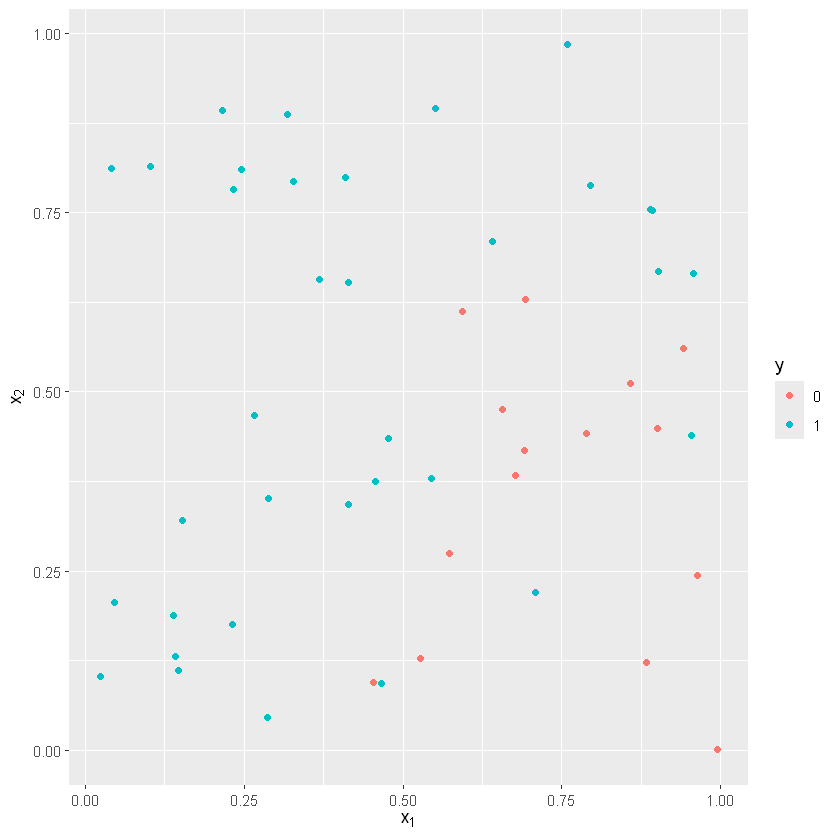

In [1]:
#| label: setup_data
library(ggplot2)

set.seed(123)
n <- 50
X <- matrix(runif(2 * n), ncol = 2)
X_model <- cbind(1, X)                                 # n x 3 design
y <- -((X_model %*% c(0.3, -1, 1) + rnorm(n, 0, 0.3) < 0) - 1)
df <- as.data.frame(X); df$type <- as.character(y)

ggplot(df) +
  geom_point(aes(x = V1, y = V2, color = type)) +
  xlab(expression(x[1])) + ylab(expression(x[2])) +
  labs(color = "y")

::: callout-note
**R vs. Python parity.** R's `set.seed(123)` and Python's `np.random.seed(123)` use *different* RNGs and call them in different orders, so the simulated data differ between languages. NR and GN are deterministic given the data, so the *trajectories* (as printed below) will not match between languages — but the *qualitative behavior* (NR converging quadratically, GN converging more slowly) should match.
:::

## (a) Gradient of the Brier loss

Show that

$$\nabla_{\bm{\theta}} \mathcal{R}_\text{emp} = \sum_{i=1}^n 2 \cdot \frac{y^{(i)} \exp(f^{(i)}) - (\exp(-f^{(i)}) + 1)^{-1}}{(\exp(f^{(i)}) + 1)^2} \cdot \tilde{\xv}^{(i)}$$

where $\tilde{\xv}^{(i)} = (1, x_1^{(i)}, x_2^{(i)})^\top$ and $f^{(i)} = \tilde{\xv}^{(i)\top} \bm{\theta}$.

**Solution.**

Define $s:\R\rightarrow\R, f \mapsto \frac{1}{1 + \exp(f)}.$

$$\begin{aligned}
\nabla_{\bm{\theta}}\mathcal{R}_{\text{emp}} &= \nabla_{\bm{\theta}}\sum^n_{i=1}\Vert y^{(i)} - f(\mathbf{x}^{(i)}) \Vert^2_2 = \sum^n_{i=1}\frac{d}{df}\Vert y^{(i)} - s(f^{(i)}) \Vert^2_2 \cdot \nabla_{\bm{\theta}} f^{(i)} \\
&= \sum^n_{i=1}2\frac{y^{(i)}(\exp(f^{(i)}) + 1) - 1}{\exp(f^{(i)}) + 1} \cdot \frac{\exp(f^{(i)})}{(\exp(f^{(i)}) + 1)^2} \tilde{\mathbf{x}}^{(i)} \\
&= \sum^n_{i=1}2\frac{y^{(i)}(\exp(f^{(i)}) + 1) - 1}{\exp(f^{(i)}) + 1} \cdot \frac{\frac{\exp(f^{(i)})}{\exp(f^{(i)}) + 1}}{\exp(f^{(i)}) + 1} \tilde{\mathbf{x}}^{(i)} \\
&= \sum^n_{i=1}2\frac{y^{(i)}(\exp(f^{(i)})) - \frac{\exp(f^{(i)})}{\exp(f^{(i)}) + 1}}{(\exp(f^{(i)}) + 1)^2} \tilde{\mathbf{x}}^{(i)} \\
&= \sum^n_{i=1}2\frac{y^{(i)}(\exp(f^{(i)})) - (\exp(-f^{(i)}) + 1)^{-1}}{(\exp(f^{(i)}) + 1)^2} \tilde{\mathbf{x}}^{(i)}
\end{aligned}$$

## (b) Hessian of the Brier loss

Show that

$$\nabla^2_{\bm{\theta}} \mathcal{R}_\text{emp} = \sum_{i=1}^n 2 \cdot \frac{\exp(f^{(i)})\big(y^{(i)}(1 - \exp(2f^{(i)})) - 1 + 2\exp(f^{(i)})\big)}{(\exp(f^{(i)}) + 1)^4} \cdot \tilde{\xv}^{(i)} \tilde{\xv}^{(i)\top}.$$

**Solution.**

Introduce the shorthand $E := \exp(f^{(i)})$ (so $\exp(-f^{(i)}) = E^{-1}$) and drop the per-sample index $i$ inside the sum ($y := y^{(i)}$, $\tilde{\mathbf{x}} := \tilde{\mathbf{x}}^{(i)}$). Differentiating the gradient from (a):

$$\begin{aligned}
\nabla^2_{\bm{\theta}}\mathcal{R}_{\text{emp}}
&= \sum^n_{i=1}\frac{d}{df}\,2\frac{yE - (E^{-1} + 1)^{-1}}{(E + 1)^2}\,\tilde{\mathbf{x}}\,\nabla_{\bm{\theta}} f^\top \\
&= \sum^n_{i=1}2\frac{\big(yE - (E^{-1} + 1)^{-2}E^{-1}\big)(E + 1)^2 - \big(yE - (E^{-1} + 1)^{-1}\big)\,2(E + 1)E}{(E + 1)^4}\,\tilde{\mathbf{x}}\,\tilde{\mathbf{x}}^\top \\
&= \sum^n_{i=1}2\frac{yE(E + 1)^2 - E - \big(2yE(E + 1) - 2E\big)E}{(E + 1)^4}\,\tilde{\mathbf{x}}\,\tilde{\mathbf{x}}^\top \\
&= \sum^n_{i=1}2\frac{E\big(y(E + 1)^2 - 1 - 2yE(E + 1) + 2E\big)}{(E + 1)^4}\,\tilde{\mathbf{x}}\,\tilde{\mathbf{x}}^\top \\
&= \sum^n_{i=1}2\frac{E\big(y(E^2 + 2E + 1 - 2E^2 - 2E) - 1 + 2E\big)}{(E + 1)^4}\,\tilde{\mathbf{x}}\,\tilde{\mathbf{x}}^\top \\
&= \sum^n_{i=1}2\frac{E\big(y(1 - E^2) - 1 + 2E\big)}{(E + 1)^4}\,\tilde{\mathbf{x}}\,\tilde{\mathbf{x}}^\top
\end{aligned}$$

## (c) Non-convexity

Show that $\mathcal{R}_\text{emp}$ is not convex in general.

**Solution.**

Assume, e.g., there is only one observation with $y^{(1)} = 0$ then

$$\nabla^2_{\bm{\theta}}\mathcal{R}_{\text{emp}} = \frac{2\exp(f^{(1)})(2\exp(f^{(1)}) - 1)}{(\exp(f^{(1)}) + 1)^4}\underbrace{\tilde{\mathbf{x}}^{(1)}{\tilde{\mathbf{x}}}^{(1)\top}}_{\text{p.s.d.}}.$$

If a p.s.d. matrix is multiplied with a negative number it becomes a n.s.d. matrix, i.e., $\nabla^2_{\bm{\theta}}\mathcal{R}_{\text{emp}}$ is n.s.d. if $2\exp(f^{(1)}) < 1 \iff f^{(i)} < \ln(0.5).$ This condition trivially holds, e.g., if $\bm{\theta} = (\ln(0.5) - 1, 0, 0)^\top.$

## (d) Newton-Raphson

Implement Newton-Raphson to minimize $\mathcal{R}_\text{emp}$. Run for $30$ iterations starting at $\bm{\theta}^{[0]} = \mathbf{0}$. Plot $\mathcal{R}_\text{emp}$ and the parameter trajectory.

NR final theta = (-2.0871, +6.6674, -5.9675), R_emp = 6.1561


Warning message:
"package 'gridExtra' was built under R version 4.4.3"


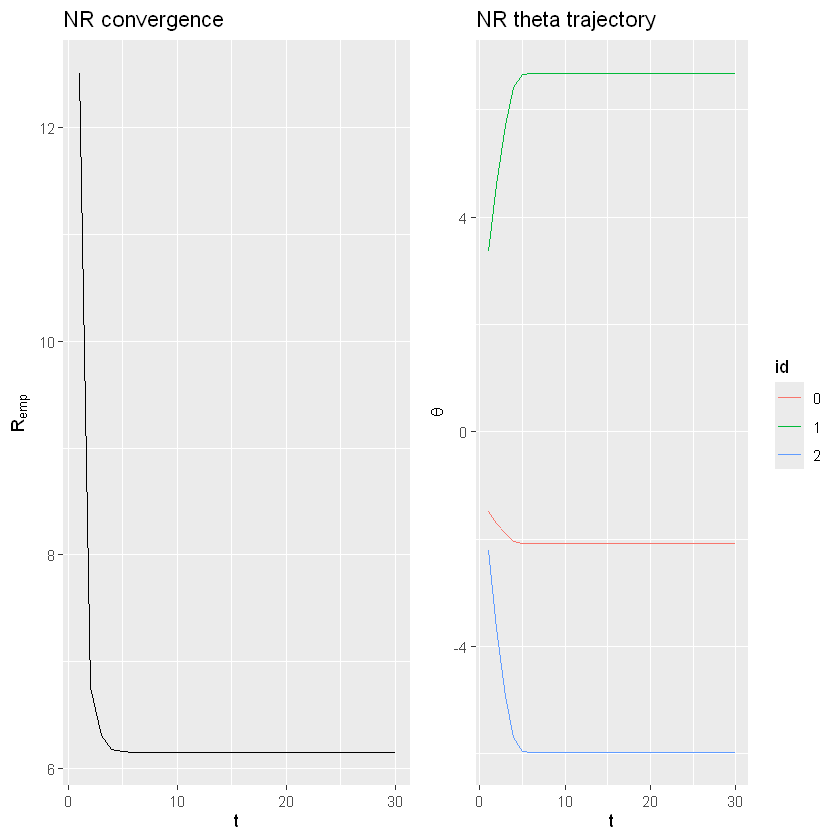

In [2]:
#| label: solution_d_code
# Brier loss + gradient + Hessian using named intermediates from solution (b):
# E = exp(f), D = E + 1, s = 1/D = pi(x).
remp <- function(theta) {
  E <- exp(X_model %*% theta)
  sum((y - 1 / (E + 1))^2)
}

grad_remp <- function(theta) {
  E <- exp(X_model %*% theta)
  inner <- 2 * (y * E - E / (E + 1)) / (E + 1)^2     # per-sample d_R/d_f
  c(t(inner) %*% X_model)                            # chain rule x df/dtheta
}

hess_remp <- function(theta) {
  E <- exp(X_model %*% theta)
  diag_factor <- as.numeric(2 * E * (y * (1 - E^2) - 1 + 2 * E) / (E + 1)^4)
  t(X_model) %*% (diag_factor * X_model)
}

# Newton-Raphson loop
theta <- c(0, 0, 0)
remps_nr <- numeric(30)
thetas_nr <- matrix(NA, 30, 3)
for (i in 1:30) {
  remps_nr[i] <- remp(theta)
  theta <- theta + solve(hess_remp(theta), -grad_remp(theta))
  thetas_nr[i, ] <- theta
}
cat(sprintf("NR final theta = (%+.4f, %+.4f, %+.4f), R_emp = %.4f\n",
            theta[1], theta[2], theta[3], remp(theta)))

# Diagnostic plots
library(gridExtra)
p1 <- ggplot(data.frame(t = 1:30, R = remps_nr), aes(t, R)) + geom_line() +
  ylab(expression(R[emp])) + ggtitle("NR convergence")
p2 <- ggplot(data.frame(t = rep(1:30, 3),
                        theta = c(thetas_nr),
                        id = factor(rep(0:2, each = 30)))) +
  geom_line(aes(t, theta, color = id)) +
  ylab(expression(theta)) + ggtitle("NR theta trajectory")
grid.arrange(p1, p2, ncol = 2)

For Newton-Raphson, we need to solve in each update step

$$\nabla^2_{\bm{\theta}}\mathcal{R}_{\text{emp}} \mathbf{d} = -\nabla_{\bm{\theta}}\mathcal{R}_{\text{emp}}$$

for the descend direction $\mathbf{d}.$

## (e) Gauss-Newton

Explain why Gauss-Newton is applicable here, and implement it (30 iterations, $\bm{\theta}^{[0]} = \mathbf{0}$). Compare its convergence to Newton-Raphson from (d).

In this case, we can apply Gauss-Newton since $\mathcal{R}_{\text{emp}}$ is the squared sum of the residuals

$$\mathbf{r} = (y^{(1)} - \pi(\mathbf{x}^{(1)}), \dots, y^{(n)} - \pi(\mathbf{x}^{(n)}))^\top.$$

Here, for the update step we need to compute

$$\nabla_{\bm{\theta}}\mathbf{r} = \begin{pmatrix} \frac{\exp(f^{(1)})}{(1 + \exp(f^{(1)}))^2} {\tilde{\mathbf{x}}}^{(1)\top} \\
\vdots \\
\frac{\exp(f^{(n)})}{(1 + \exp(f^{(n)}))^2}{\tilde{\mathbf{x}}}^{(n)\top}
\end{pmatrix}$$

For Gauss-Newton, we solve in each update step

$$(\nabla_{\bm{\theta}}\mathbf{r}^\top \nabla_{\bm{\theta}}\mathbf{r}) \cdot \mathbf{d} = -\nabla_{\bm{\theta}}\mathbf{r}^\top \cdot \mathbf{r}$$

for the descend direction $\mathbf{d}.$

GN final theta = (-2.0871, +6.6674, -5.9675), R_emp = 6.1561


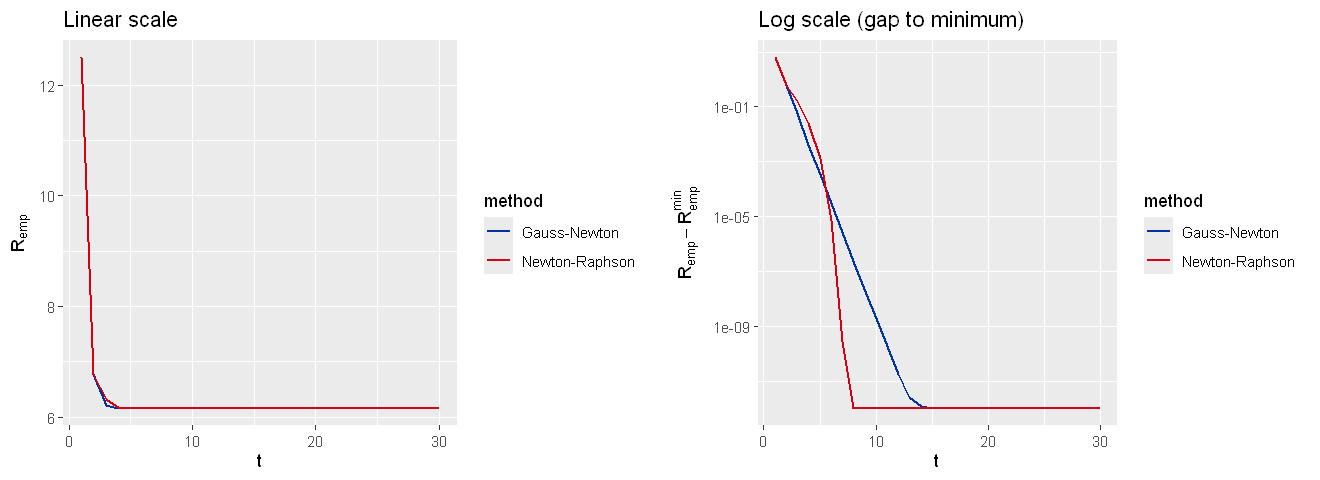

In [3]:
#| label: solution_e_code
options(repr.plot.width = 11, repr.plot.height = 4)
# Gauss-Newton: replace Hessian with J^T J where J is the residual Jacobian.
# residual r_i = y_i - pi(x_i),
# dr_i/dtheta = -pi'(f) * x_i = (E / (E+1)^2) * x_i.
theta <- c(0, 0, 0)
remps_gn <- numeric(30)
thetas_gn <- matrix(NA, 30, 3)
for (i in 1:30) {
  remps_gn[i] <- remp(theta)
  E <- exp(X_model %*% theta)
  r <- y - 1 / (E + 1)                                 # residuals
  J <- as.numeric(E / (E + 1)^2) * X_model             # residual Jacobian
  theta <- theta + solve(t(J) %*% J, -t(J) %*% r)
  thetas_gn[i, ] <- theta
}
cat(sprintf("GN final theta = (%+.4f, %+.4f, %+.4f), R_emp = %.4f\n",
            theta[1], theta[2], theta[3], remp(theta)))

# Compare NR vs GN convergence. Linear axis (left) hides the convergence-rate
# distinction once both are close to the minimum; log-axis on R_emp - R_emp_min
# (right) exposes it.
R_min <- min(remps_nr, remps_gn) - 1e-12
df_compare <- rbind(
  data.frame(t = 1:30, R = remps_nr, gap = remps_nr - R_min,
             method = "Newton-Raphson"),
  data.frame(t = 1:30, R = remps_gn, gap = remps_gn - R_min,
             method = "Gauss-Newton")
)

p_lin <- ggplot(df_compare, aes(t, R, color = method)) +
  geom_line(linewidth = 0.7) +
  scale_color_manual(values = c("Newton-Raphson" = "#D90012",
                                "Gauss-Newton"    = "#0033A0")) +
  ylab(expression(R[emp])) + ggtitle("Linear scale")
p_log <- ggplot(df_compare, aes(t, gap, color = method)) +
  geom_line(linewidth = 0.7) +
  scale_y_log10() +
  scale_color_manual(values = c("Newton-Raphson" = "#D90012",
                                "Gauss-Newton"    = "#0033A0")) +
  ylab(expression(R[emp] - R[emp]^{min})) +
  ggtitle("Log scale (gap to minimum)")
grid.arrange(p_lin, p_log, ncol = 2)